In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [29]:
df=pd.read_csv("sensor.csv")
df.tail()

,time_ms,AQI_like,vNode_V,est_AO_V,DO,Temp_C,RH_pct
284,333110399,46,0.097,0.145,1,21.3,52.5
285,333112505,52,0.102,0.153,1,21.3,52.5
286,333114611,46,0.097,0.145,1,21.3,52.7
287,333116717,42,0.093,0.139,1,21.2,52.7
288,333118823,53,0.102,0.154,1,21.2,52.8


In [30]:
depend=["time_ms","vNode_V","est_AO_V"]


X=df[depend]
Y=df["Temp_C"]


In [31]:
X_train,X_test,y_train,y_test=train_test_split(
X,Y,test_size=0.2,random_state=0
)

y_test.head()

55     21.4
182    25.7
92     29.7
209    24.0
261    21.9
Name: Temp_C, dtype: float64

In [32]:
#model training
model=LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
y_pred=model.predict(X_test)
y_pred

array([28.65876498, 25.68617705, 24.46934373, 25.080147  , 24.19406799,
       28.13301604, 24.89074649, 29.14187829, 21.22784528, 20.82767938,
       24.28950023, 23.63468105, 20.3129513 , 27.43366589, 26.05344215,
       24.24277356, 25.19474829, 23.88928988, 24.43980199, 24.61895274,
       24.41577081, 24.76167625, 25.32110243, 24.77059032, 25.26068325,
       25.84956747, 24.32929174, 23.9181832 , 23.78368622, 24.52490077,
       25.0142565 , 20.04185029, 21.01436913, 24.21740656, 25.43639125,
       23.72873823, 26.30735823, 24.98135571, 20.05007683, 26.98203399,
       26.57643588, 24.36361727, 23.32034579, 25.09935529, 24.08971659,
       27.59149622, 25.00741025, 24.7458716 , 26.24491569, 24.380065  ,
       26.72466995, 24.27847403, 24.04854481, 25.23320397, 24.65056738,
       24.77472581, 23.33886133, 20.53737009])

In [35]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

# below are the different errors which we get during evaluation


MAE: 2.730400875985106
MSE: 11.005424534951205
R2 Score: 0.23054744543389538


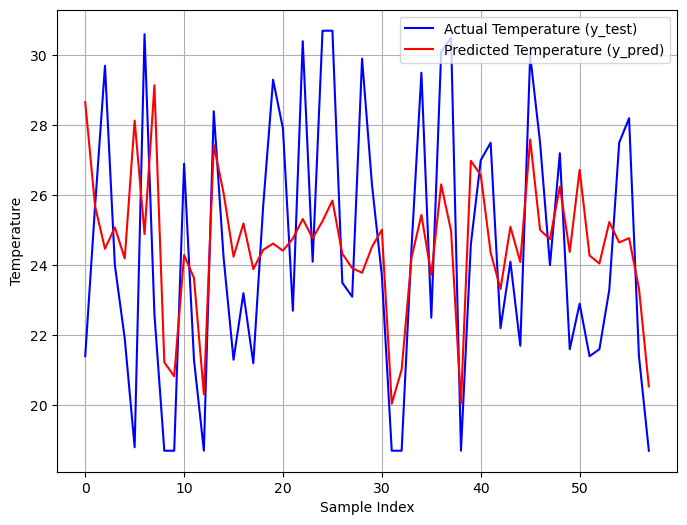

In [42]:
plt.figure(figsize=(8,6))

# Actual values
plt.plot(
    y_test.values,
    color="blue",
    label="Actual Temperature (y_test)"
)

# Predicted values
plt.plot(
    y_pred,
    color="red",
    label="Predicted Temperature (y_pred)"
)

plt.xlabel("Sample Index")
plt.ylabel("Temperature")
plt.legend()
plt.grid(True)
plt.show()


In [44]:
residuals = y_test - y_pred
threshold = 3 * np.std(residuals)
anomalies = np.abs(residuals) > threshold

print("Total anomalies detected:", anomalies.sum())


Total anomalies detected: 0


In [46]:
time_test = X_test["time_ms"].values
sorted_idx = np.argsort(time_test)

time_sorted = time_test[sorted_idx]
y_test_sorted = y_test.values[sorted_idx]
y_pred_sorted = y_pred[sorted_idx]
anomalies_sorted = anomalies.values[sorted_idx]


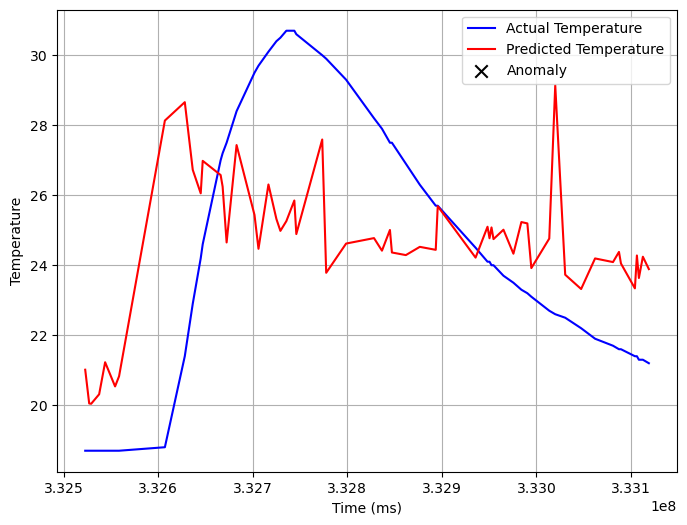

In [47]:
plt.figure(figsize=(8,6))

# Actual
plt.plot(
    time_sorted,
    y_test_sorted,
    color="blue",
    label="Actual Temperature"
)

# Predicted
plt.plot(
    time_sorted,
    y_pred_sorted,
    color="red",
    label="Predicted Temperature"
)

# Anomalies
plt.scatter(
    time_sorted[anomalies_sorted],
    y_test_sorted[anomalies_sorted],
    color="black",
    marker="x",
    s=80,
    label="Anomaly"
)

plt.xlabel("Time (ms)")
plt.ylabel("Temperature")
plt.legend()
plt.grid(True)
plt.show()
